<a href="https://colab.research.google.com/github/AnujikaSasindi/sri-lanka-tourism-sentiment-analysis/blob/Main/Try_Again_3__Sentiment_Prediction_Model_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Installations**

In [ ]:
!pip install -q transformers datasets accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

import evaluate

**Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_excel('balanced_cleaned_dataset_1_(sentiment + attarction category).xlsx')

print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Saving balanced_cleaned_dataset_1_(sentiment + attarction category).xlsx to balanced_cleaned_dataset_1_(sentiment + attarction category).xlsx
Shape of dataset: (7164, 11)

Column names:
['Location_Name', 'Located_City', 'Location_Type', 'Title', 'Text', 'Review_Text', 'Rating', 'Sentiment', 'Cluster_Text', 'Attraction_Cluster', 'Attraction_Category']

First 5 rows:


,Location_Name,Located_City,Location_Type,Title,Text,Review_Text,Rating,Sentiment,Cluster_Text,Attraction_Cluster,Attraction_Category
0,Handunugoda Tea Estate,Ahangama,Farms,Wonderful Experience,This was our third tea factory tour during our...,Wonderful Experience This was our third tea fa...,5,Positive,Handunugoda Tea Estate Farms Wonderful Experie...,4,Tea Plantations & Factory Tours
1,Glenloch Tea Factory,Katukitula,Farms,In-TEA-resting,A worth visit for everyone who drinks tea. Gui...,In-TEA-resting A worth visit for everyone who ...,4,Positive,Glenloch Tea Factory Farms In-TEA-resting A wo...,4,Tea Plantations & Factory Tours
2,Handunugoda Tea Estate,Ahangama,Farms,"The best tea experience, great history","Hidden away in a beautiful stretch of green, t...","The best tea experience, great history Hidden ...",5,Positive,Handunugoda Tea Estate Farms The best tea expe...,4,Tea Plantations & Factory Tours
3,Bluefield Tea Gardens,Nuwara Eliya,Farms,Informative tour,We really enjoyed our tour at the Bluefield te...,Informative tour We really enjoyed our tour at...,5,Positive,Bluefield Tea Gardens Farms Informative tour W...,4,Tea Plantations & Factory Tours
4,Ceylon Tea Museum,Kandy,Museums,Under appreciated - well worth,We spend a few enjoyable hours here. It is aro...,Under appreciated - well worth We spend a few ...,4,Positive,Ceylon Tea Museum Museums Under appreciated - ...,4,Tea Plantations & Factory Tours


In [ ]:
df = df[["Title", "Text", "Sentiment"]]

df = df.dropna(subset=["Title", "Text", "Sentiment"])

df = df.drop_duplicates()

df["Combined_Text"] = (
    df["Title"].astype(str).str.strip() + " " +
    df["Text"].astype(str).str.strip()
)


df = df[["Combined_Text", "Sentiment"]]

df.reset_index(drop=True, inplace=True)

df.head()

,Combined_Text,Sentiment
0,Wonderful Experience This was our third tea fa...,Positive
1,In-TEA-resting A worth visit for everyone who ...,Positive
2,"The best tea experience, great history Hidden ...",Positive
3,Informative tour We really enjoyed our tour at...,Positive
4,Under appreciated - well worth We spend a few ...,Positive


In [ ]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["Sentiment"])

print(label_encoder.classes_)

['Negative' 'Neutral' 'Positive']


**Train / Validation / Test Split**

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["label"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1765,
    random_state=42,
    stratify=train_df["label"]
)

print(len(train_df))
print(len(val_df))
print(len(test_df))

5012
1075
1075


In [ ]:
train_dataset = Dataset.from_pandas(train_df[["Combined_Text","label"]])
val_dataset = Dataset.from_pandas(val_df[["Combined_Text","label"]])
test_dataset = Dataset.from_pandas(test_df[["Combined_Text","label"]])

**Metric Function**

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


**Fine-tuning BERT**

In [ ]:
BERT_MODEL_NAME = "bert-base-uncased"

In [ ]:
from transformers import AutoTokenizer

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

In [ ]:
def bert_tokenize(batch):
    return bert_tokenizer(
        batch["Combined_Text"],
        truncation=True,
        padding=True,
        max_length=128
    )

In [ ]:
bert_train_tokenized = train_dataset.map(bert_tokenize, batched=True)
bert_val_tokenized = val_dataset.map(bert_tokenize, batched=True)
bert_test_tokenized = test_dataset.map(bert_tokenize, batched=True)

Map:   0%|          | 0/5012 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer)

In [ ]:
from transformers import AutoModelForSequenceClassification

bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=3
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

bert_training_args = TrainingArguments(
    output_dir="/content/BERT",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    seed=42
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

bert_trainer = Trainer(
    model=bert_model,
    args=bert_training_args,
    train_dataset=bert_train_tokenized,
    eval_dataset=bert_val_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
bert_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.558587,0.497148,0.786047,0.759588,0.739904,0.748397
2,0.443510,0.518502,0.780465,0.738706,0.747913,0.742290
3,0.310006,0.545737,0.797209,0.776868,0.747317,0.760078


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=942, training_loss=0.4715651301568228, metrics={'train_runtime': 448.3178, 'train_samples_per_second': 33.539, 'train_steps_per_second': 2.101, 'total_flos': 989043337239552.0, 'train_loss': 0.4715651301568228, 'epoch': 3.0})

In [ ]:
bert_results = bert_trainer.evaluate(bert_test_tokenized)

bert_results

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.310006,0.562416,3,0.790698,0.767950,0.750608,0.758005


{'eval_loss': 0.5624157190322876,
 'eval_accuracy': 0.7906976744186046,
 'eval_precision': 0.7679497709663122,
 'eval_recall': 0.7506078369472592,
 'eval_f1': 0.7580049424959604}

In [ ]:
predictions = bert_trainer.predict(bert_test_tokenized)

y_pred = np.argmax(predictions.predictions, axis=1)

y_true = predictions.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.78      0.73      0.75       172
     Neutral       0.68      0.61      0.64       325
    Positive       0.85      0.91      0.88       578

    accuracy                           0.79      1075
   macro avg       0.77      0.75      0.76      1075
weighted avg       0.78      0.79      0.79      1075



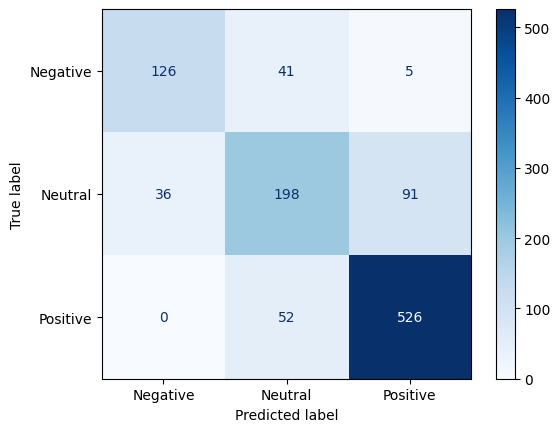

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.show()

In [ ]:
# Didn't run

bert_trainer.save_model("/content/BERT_Final")

bert_tokenizer.save_pretrained("/content/BERT_Final")

**Fine-tuning DistilBERT**

In [ ]:
DistilBERT_MODEL_NAME = "distilbert-base-uncased"

In [ ]:
from transformers import AutoTokenizer

distilbert_tokenizer = AutoTokenizer.from_pretrained(DistilBERT_MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
def distilbert_tokenize(batch):
    return distilbert_tokenizer(
        batch["Combined_Text"],
        truncation=True,
        padding=True,
        max_length=128
    )

In [ ]:
distilbert_train_tokenized = train_dataset.map(distilbert_tokenize, batched=True)
distilbert_val_tokenized = val_dataset.map(distilbert_tokenize, batched=True)
distilbert_test_tokenized = test_dataset.map(distilbert_tokenize, batched=True)

Map:   0%|          | 0/5012 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=distilbert_tokenizer)

In [ ]:
from transformers import AutoModelForSequenceClassification

distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    DistilBERT_MODEL_NAME,
    num_labels=3
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

distilbert_training_args = TrainingArguments(
    output_dir="/content/DistilBERT",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    seed=42
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

distilbert_trainer = Trainer(
    model=distilbert_model,
    args=distilbert_training_args,
    train_dataset=distilbert_train_tokenized,
    eval_dataset=distilbert_val_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
distilbert_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.571160,0.522502,0.782326,0.754726,0.734397,0.742645
2,0.432987,0.524787,0.787907,0.750857,0.747473,0.749009
3,0.359479,0.546502,0.786977,0.757419,0.738685,0.746995


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=942, training_loss=0.48212810686439467, metrics={'train_runtime': 291.423, 'train_samples_per_second': 51.595, 'train_steps_per_second': 3.232, 'total_flos': 497953831689216.0, 'train_loss': 0.48212810686439467, 'epoch': 3.0})

In [ ]:
distilbert_results = distilbert_trainer.evaluate(distilbert_test_tokenized)

distilbert_results

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.359479,0.540277,3,0.775814,0.736835,0.738730,0.735838


{'eval_loss': 0.5402765274047852,
 'eval_accuracy': 0.7758139534883721,
 'eval_precision': 0.7368345473358927,
 'eval_recall': 0.7387303699760447,
 'eval_f1': 0.7358376755877171}

In [ ]:
predictions = distilbert_trainer.predict(distilbert_test_tokenized)

y_pred = np.argmax(predictions.predictions, axis=1)

y_true = predictions.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.70      0.75      0.72       172
     Neutral       0.66      0.56      0.61       325
    Positive       0.85      0.90      0.88       578

    accuracy                           0.78      1075
   macro avg       0.74      0.74      0.74      1075
weighted avg       0.77      0.78      0.77      1075



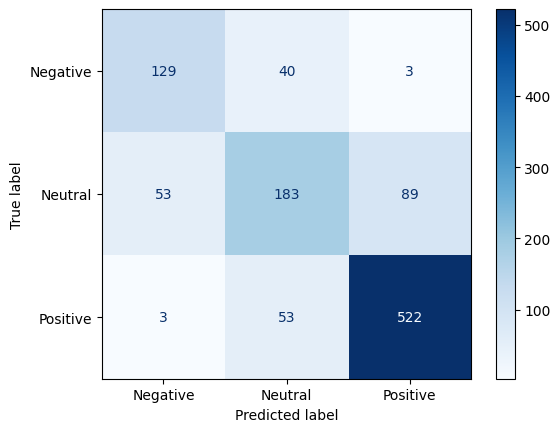

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.show()

In [ ]:
# Didn't run

distilbert_trainer.save_model("/content/DistilBERT_Final")

distilbert_tokenizer.save_pretrained("/content/DistilBERT_Final")

**Fine-tuning RoBERTa**

In [ ]:
RoBERTa_MODEL_NAME = "roberta-base"

In [ ]:
from transformers import AutoTokenizer

roberta_tokenizer = AutoTokenizer.from_pretrained(RoBERTa_MODEL_NAME)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
def roberta_tokenize(batch):
    return roberta_tokenizer(
        batch["Combined_Text"],
        truncation=True,
        padding=True,
        max_length=128
    )

In [ ]:
roberta_train_tokenized = train_dataset.map(roberta_tokenize, batched=True)
roberta_val_tokenized = val_dataset.map(roberta_tokenize, batched=True)
roberta_test_tokenized = test_dataset.map(roberta_tokenize, batched=True)

Map:   0%|          | 0/5012 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

In [ ]:
from transformers import AutoModelForSequenceClassification

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    RoBERTa_MODEL_NAME,
    num_labels=3
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

roberta_training_args = TrainingArguments(
    output_dir="/content/RoBERTa",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    seed=42
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=roberta_train_tokenized,
    eval_dataset=roberta_val_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
roberta_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.544019,0.494082,0.794419,0.783324,0.753624,0.764479
2,0.462933,0.484838,0.795349,0.759423,0.763527,0.758427
3,0.319232,0.501766,0.810233,0.786017,0.770828,0.777544


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=942, training_loss=0.4719631778206795, metrics={'train_runtime': 473.1382, 'train_samples_per_second': 31.779, 'train_steps_per_second': 1.991, 'total_flos': 989043337239552.0, 'train_loss': 0.4719631778206795, 'epoch': 3.0})

In [ ]:
roberta_results = roberta_trainer.evaluate(roberta_test_tokenized)

roberta_results

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.319232,0.507488,3,0.807442,0.785122,0.769996,0.776838


{'eval_loss': 0.5074875354766846,
 'eval_accuracy': 0.8074418604651162,
 'eval_precision': 0.7851223980928754,
 'eval_recall': 0.7699961828359672,
 'eval_f1': 0.7768383968086474}

In [ ]:
predictions = roberta_trainer.predict(roberta_test_tokenized)

y_pred = np.argmax(predictions.predictions, axis=1)

y_true = predictions.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.79      0.74      0.77       172
     Neutral       0.70      0.65      0.68       325
    Positive       0.87      0.91      0.89       578

    accuracy                           0.81      1075
   macro avg       0.79      0.77      0.78      1075
weighted avg       0.80      0.81      0.80      1075



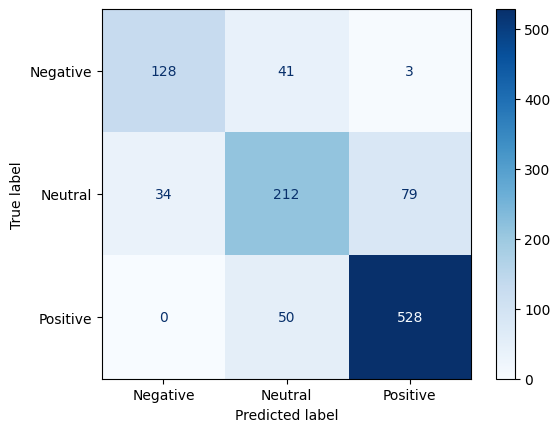

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.show()

In [ ]:
# Didn't run

roberta_trainer.save_model("/content/RoBERTa_Final")

roberta_tokenizer.save_pretrained("/content/RoBERTa_Final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/RoBERTa_Final/tokenizer_config.json',
 '/content/RoBERTa_Final/tokenizer.json')

**FINAL ROBERTA MODEL TRAINING** - Without adjustments

In [ ]:
final_train_df = pd.concat([train_df, val_df]).reset_index(drop=True)

print(final_train_df.shape)

(6087, 3)


In [ ]:
from datasets import Dataset

final_train_dataset = Dataset.from_pandas(
    final_train_df[["Combined_Text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["Combined_Text", "label"]]
)

In [ ]:
from transformers import AutoTokenizer

RoBERTa_MODEL_NAME = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(RoBERTa_MODEL_NAME)

def roberta_tokenize(batch):
    return roberta_tokenizer(
        batch["Combined_Text"],
        truncation=True,
        padding=True,
        max_length=128
    )

In [ ]:
final_train_tokenized = final_train_dataset.map(roberta_tokenize, batched=True)
test_tokenized = test_dataset.map(roberta_tokenize, batched=True)

Map:   0%|          | 0/6087 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

In [ ]:
from transformers import AutoModelForSequenceClassification

final_model = AutoModelForSequenceClassification.from_pretrained(
    RoBERTa_MODEL_NAME,
    num_labels=3
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

final_training_args = TrainingArguments(
    output_dir="/content/RoBERTa_Final_Model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,

    logging_steps=50,
    save_strategy="no",
    report_to="none",
    seed=42
)

In [ ]:
from transformers import Trainer

final_trainer = Trainer(
    model=final_model,
    args=final_training_args,
    train_dataset=final_train_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
final_trainer.train()

Step,Training Loss
50,0.931749
100,0.761416
150,0.629235
200,0.570476
250,0.555975
300,0.606549
350,0.510987
400,0.512885
450,0.426011
500,0.384091


TrainOutput(global_step=1143, training_loss=0.47067543673911644, metrics={'train_runtime': 454.8685, 'train_samples_per_second': 40.146, 'train_steps_per_second': 2.513, 'total_flos': 1201178530282752.0, 'train_loss': 0.47067543673911644, 'epoch': 3.0})

In [ ]:
test_results = final_trainer.evaluate(test_tokenized)
print(test_results)

Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
0.343267,0.553119,1143,0.804651,0.781904,0.765181,0.770705


{'eval_loss': 0.5531191229820251, 'eval_accuracy': 0.8046511627906977, 'eval_precision': 0.7819040048362927, 'eval_recall': 0.7651813565581973, 'eval_f1': 0.7707049154417575}


In [ ]:
predictions = final_trainer.predict(test_tokenized)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.78      0.77      0.77       172
     Neutral       0.72      0.59      0.65       325
    Positive       0.85      0.93      0.89       578

    accuracy                           0.80      1075
   macro avg       0.78      0.77      0.77      1075
weighted avg       0.80      0.80      0.80      1075



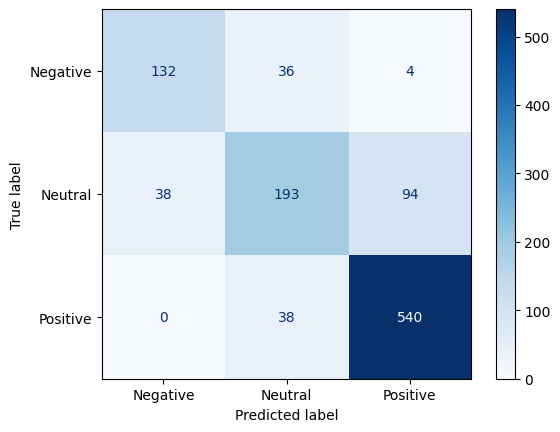

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.show()

In [ ]:
final_trainer.save_model("/content/RoBERTa_FINAL_MODEL")
roberta_tokenizer.save_pretrained("/content/RoBERTa_FINAL_MODEL")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/RoBERTa_FINAL_MODEL/tokenizer_config.json',
 '/content/RoBERTa_FINAL_MODEL/tokenizer.json')

In [ ]:
!zip -r RoBERTa_FINAL_MODEL.zip /content/RoBERTa_FINAL_MODEL

updating: content/RoBERTa_FINAL_MODEL/ (stored 0%)
updating: content/RoBERTa_FINAL_MODEL/config.json (deflated 53%)
updating: content/RoBERTa_FINAL_MODEL/training_args.bin (deflated 53%)
updating: content/RoBERTa_FINAL_MODEL/tokenizer_config.json (deflated 51%)
updating: content/RoBERTa_FINAL_MODEL/tokenizer.json (deflated 82%)
updating: content/RoBERTa_FINAL_MODEL/model.safetensors (deflated 12%)


In [ ]:
from google.colab import files
files.download("RoBERTa_FINAL_MODEL.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**FINAL ROBERTA MODEL TRAINING** - With Class Weights

In [ ]:
final_model_with_cw = AutoModelForSequenceClassification.from_pretrained(
    RoBERTa_MODEL_NAME,
    num_labels=3
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1, 2])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=final_train_df["label"]
)

print(class_weights)

[2.08530319 1.10271739 0.61973122]


In [ ]:
import torch

class_weights = torch.tensor(class_weights, dtype=torch.float)

In [ ]:
from transformers import Trainer
import torch.nn as nn

class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
final_trainer_with_cw = WeightedLossTrainer(
    model=final_model_with_cw,
    args=final_training_args,
    train_dataset=final_train_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

In [ ]:
final_trainer_with_cw.train()

Step,Training Loss
50,0.489391
100,0.430485
150,0.365063
200,0.315998
250,0.261980
300,0.329346
350,0.287851
400,0.268497
450,0.162247
500,0.151660


TrainOutput(global_step=1143, training_loss=0.241561883390732, metrics={'train_runtime': 455.2248, 'train_samples_per_second': 40.114, 'train_steps_per_second': 2.511, 'total_flos': 1201178530282752.0, 'train_loss': 0.241561883390732, 'epoch': 3.0})

In [ ]:
test_results = final_trainer_with_cw.evaluate(test_tokenized)
print(test_results)

Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
0.180455,1.092660,1143,0.787907,0.748759,0.752035,0.749876


{'eval_loss': 1.0926597118377686, 'eval_accuracy': 0.7879069767441861, 'eval_precision': 0.7487594186725927, 'eval_recall': 0.7520347753960049, 'eval_f1': 0.7498760246923121}


In [ ]:
predictions = final_trainer_with_cw.predict(test_tokenized)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.70      0.74      0.72       172
     Neutral       0.67      0.62      0.65       325
    Positive       0.87      0.90      0.88       578

    accuracy                           0.79      1075
   macro avg       0.75      0.75      0.75      1075
weighted avg       0.78      0.79      0.79      1075



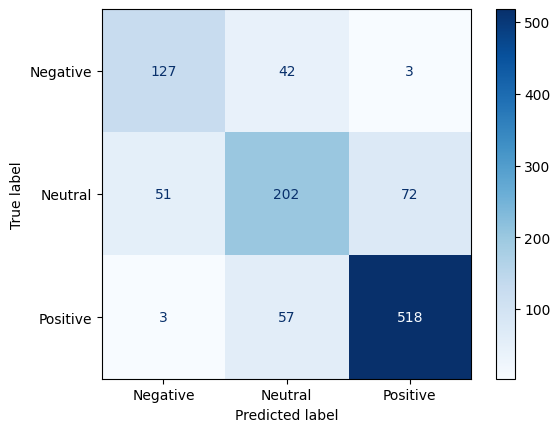

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.show()

**FINAL ROBERTA MODEL TRAINING** - With ROS

In [ ]:
!pip install -q imbalanced-learn

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X = final_train_df["Combined_Text"].values.reshape(-1, 1)
y = final_train_df["label"]

X_res, y_res = ros.fit_resample(X, y)

print("Before:", np.bincount(y))
print("After:", np.bincount(y_res))

Before: [ 973 1840 3274]
After: [3274 3274 3274]


In [ ]:
balanced_train_df = pd.DataFrame({
    "Combined_Text": X_res.flatten(),
    "label": y_res
}).reset_index(drop=True)

In [ ]:
from datasets import Dataset

final_train_dataset = Dataset.from_pandas(balanced_train_df)
test_dataset = Dataset.from_pandas(test_df[["Combined_Text", "label"]])

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def tokenize(batch):
    return tokenizer(
        batch["Combined_Text"],
        truncation=True,
        padding=True,
        max_length=128
    )

In [ ]:
train_tokenized = final_train_dataset.map(tokenize, batched=True)
test_tokenized = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/9822 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=3
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="/content/RoBERTa_ROS",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,

    logging_steps=50,
    save_strategy="no",
    report_to="none",
    seed=42
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Step,Training Loss
50,1.050189
100,0.681665
150,0.586567
200,0.595043
250,0.609831
300,0.538225
350,0.572618
400,0.471224
450,0.520177
500,0.467631


TrainOutput(global_step=1842, training_loss=0.35948596326846644, metrics={'train_runtime': 735.6244, 'train_samples_per_second': 40.056, 'train_steps_per_second': 2.504, 'total_flos': 1938224991693312.0, 'train_loss': 0.35948596326846644, 'epoch': 3.0})

In [ ]:
results = trainer.evaluate(test_tokenized)
print(results)

Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
0.136197,0.788228,1842,0.796279,0.762542,0.757688,0.759120


{'eval_loss': 0.7882281541824341, 'eval_accuracy': 0.7962790697674419, 'eval_precision': 0.7625424044653965, 'eval_recall': 0.7576884905282748, 'eval_f1': 0.7591197515449811}


In [ ]:
predictions = trainer.predict(test_tokenized)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.73      0.74      0.74       172
     Neutral       0.69      0.62      0.65       325
    Positive       0.86      0.91      0.89       578

    accuracy                           0.80      1075
   macro avg       0.76      0.76      0.76      1075
weighted avg       0.79      0.80      0.79      1075



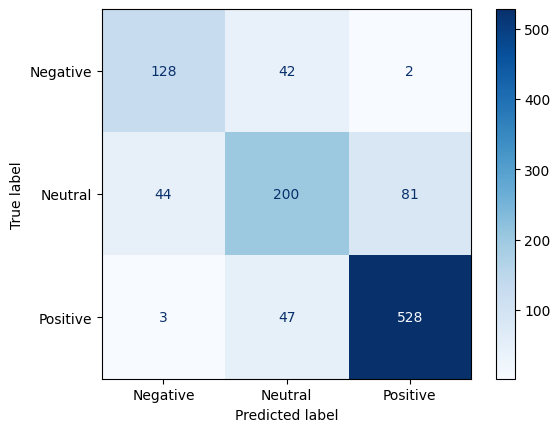

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.show()

In [ ]:
trainer.save_model("/content/RoBERTa_FINAL_MODEL_ROS")
tokenizer.save_pretrained("/content/RoBERTa_FINAL_MODEL_ROS")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/RoBERTa_FINAL_MODEL_ROS/tokenizer_config.json',
 '/content/RoBERTa_FINAL_MODEL_ROS/tokenizer.json')

In [ ]:
!zip -r RoBERTa_FINAL_MODEL_ROS.zip /content/RoBERTa_FINAL_MODEL_ROS

  adding: content/RoBERTa_FINAL_MODEL_ROS/ (stored 0%)
  adding: content/RoBERTa_FINAL_MODEL_ROS/config.json (deflated 53%)
  adding: content/RoBERTa_FINAL_MODEL_ROS/training_args.bin (deflated 53%)
  adding: content/RoBERTa_FINAL_MODEL_ROS/tokenizer_config.json (deflated 51%)
  adding: content/RoBERTa_FINAL_MODEL_ROS/tokenizer.json (deflated 82%)
  adding: content/RoBERTa_FINAL_MODEL_ROS/model.safetensors (deflated 12%)


In [ ]:
from google.colab import files
files.download("RoBERTa_FINAL_MODEL_ROS.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json

input_file = "/content/drive/MyDrive/Colab Notebooks/Try Again_3_ Sentiment Prediction Model_1_1.ipynb"
output_file = "/content/drive/MyDrive/Colab Notebooks/Try Again_3_ Sentiment Prediction Model_1_1.ipynb"

with open(input_file, "r", encoding="utf-8") as f:
    nb = json.load(f)

# Remove broken widget metadata
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1)

print("Clean notebook saved for GitHub:", output_file)

Clean notebook saved for GitHub: /content/drive/MyDrive/Colab Notebooks/Try Again_3_ Sentiment Prediction Model_1_1.ipynb
